<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>99221 למידה מרובת סוכנים</p>
<p>מטלה 3</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבוא:</p>
<ul>
<li>מטרת המטלה — מעבר מ-critics מרכזיים (מטלה 2) לאלגוריתמי פירוק ערך במשימות עם תגמול משותף, באמצעות אותו codebase רשמי של ספר הקורס</li>
<li>האלגוריתמים — IDQN: כל סוכן מאמן רשת Q עצמאית ומתייחס לשאר כחלק מהסביבה; VDN: ערך-הפעולה המשותף נאמד כסכום פונקציות התועלת של הסוכנים (פירוק אדיטיבי); QMIX: הכללה של VDN — רשת ערבוב מותנית-מצב המשלבת את התועלות באופן מונוטוני</li>
<li>חלק ראשון — בדיקת שפיות של IDQN עם תגמול משותף (CooperativeReward) במשימה Foraging-8x8-2p-3f, וריצה עצמית אופציונלית של כמיליון צעדים</li>
<li>חלק שני — השוואת שלושת האלגוריתמים על נתוני האימון המצורפים לקורס (5 seeds, 4 מיליון צעדים), כולל מדדי loss ו-epsilon</li>
<li>חלק שלישי — סרטוני התקדמות: לכל ריצה מצורפים חמישה סרטוני rollout לאורך האימון (מ-200 אלף ועד 3.8 מיליון צעדים)</li>
<li>חלק רביעי — סביבת SMAClite: השוואת שלושת האלגוריתמים בשני תרחישים (2s3z ו-2s_vs_1sc, 3 seeds כל אחד) וניתוח התנהגויות מהסרטונים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הכנת הסביבה — שכפול ה-codebase הרשמי של הספר מ-GitHub, התקנת התלויות והתקנתו כחבילה, והתקנת סביבות lb-foraging ו-SMAClite. xvfb ו-libglu1-mesa מותקנים למקרה שנרצה להפיק סרטון משלנו באמצעות eval.py (במטלה זו הסרטונים מסופקים, כך שזה גיבוי בלבד).</p>
</div>

In [1]:
!git clone -q --depth 1 https://github.com/marl-book/codebase.git marl-book-codebase
!pip install -q click einops "gymnasium<1.0.0" hydra-core==1.3.2 hydra-submitit-launcher imageio imageio-ffmpeg matplotlib pandas seaborn munch pyyaml torch
!pip install -q --no-deps -e marl-book-codebase
!pip install -q "git+https://github.com/uoe-agents/lb-foraging.git" "git+https://github.com/uoe-agents/smaclite.git"
!apt-get install -y -qq xvfb libglu1-mesa > /dev/null 2>&1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 4.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.5 MB/s eta 0:00:00


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא הספריות:</p>
<ul>
<li>glob — סריקת תבניות נתיבים לאיתור קובצי results.csv וקובצי הסרטונים על פני כל הסביבות, האלגוריתמים וה-seeds</li>
<li>os — עבודה עם נתיבים ויצירת תיקיית הפלט ב-Drive</li>
<li>shutil — העתקת קובצי הסרטונים ל-Drive בשמות מזהים</li>
<li>base64.b64encode ו-IPython.display (HTML, display) — הטמעת סרטוני ה-rollout בתוך המחברת</li>
<li>numpy — צבירת התשואות של כל ה-seeds למטריצה וחישוב ממוצע וסטיית תקן לאורך האימון</li>
<li>pandas — טעינת קובצי results.csv כטבלאות DataFrame וכתיבת קובצי הייצוא</li>
<li>yaml — קריאת קובצי הקונפיגורציה של הריצות המסופקות, לאימות ההיפר-פרמטרים שבהם אומנו</li>
<li>matplotlib — ויזואליזציה; נקבע סגנון ggplot אחיד לכל המחברת</li>
<li>torch — זיהוי GPU וקביעת DEVICE, המשורשר לפקודות ההרצה של ה-codebase</li>
<li>gymnasium — ממשק הסביבות שעליו בנויים lb-foraging ו-SMAClite</li>
</ul>
<p>בנוסף, מודפסות גרסאות PyTorch ו-Gymnasium וזיהוי המעבד לאימות הסביבה.</p>
</div>

In [2]:
import glob
import os
import shutil
from base64 import b64encode

import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display

import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('ggplot')

import torch
import gymnasium as gym

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'PyTorch   : {torch.__version__}')
print(f'Device    : {DEVICE}')
print(f'Gymnasium : {gym.__version__}')

PyTorch   : 2.11.0+cu128
Device    : cuda
Gymnasium : 0.29.1


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור ל-Google Drive — ריצות ה-codebase והנתונים המשוכפלים נכתבים תחת /content ונמחקים עם סגירת סשן ה-Colab, ולכן נדרש עיגון Drive לשמירת התוצרים.</p>
</div>

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת נתיב הפלט — DRIVE_PATH הוא תיקיית המטלה ב-Drive, ואליה ייכתבו בסוף המחברת קובצי ה-CSV וסרטוני ה-rollout.</p>
</div>

In [4]:
DRIVE_PATH = '/content/drive/MyDrive/MARL/HW3'
os.makedirs(DRIVE_PATH, exist_ok=True)

print('drive path:', DRIVE_PATH)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות — ריצת IDQN קצרה (100 אלף צעדים) במשימה Foraging-8x8-2p-3f עם תגמול משותף:</p>
<ul>
<li>env.wrappers="[CooperativeReward]" — ה-wrapper מעניק לכל הסוכנים תגמול זהה השווה לסכום התגמולים האינדיבידואליים; נדרש במפורש רק ל-IDQN — תצורות VDN ו-QMIX כבר מגדירות תגמול משותף בעצמן</li>
<li>eval_interval ו-log_interval הוקטנו ל-10,000 כדי לראות עקומה גם בריצה קצרה (בהנחיות הם 100,000, מותאם לריצת 4 המיליון המלאה)</li>
<li>algorithm.model.device — כמו במטלה 2, המפתח קיים גם בקונפיגורציית idqn, כך שהריצה מנצלת GPU כשקיים</li>
</ul>
</div>

In [5]:
cmd = ('cd marl-book-codebase/marlbase && python run.py +algorithm=idqn env.name="lbforaging:Foraging-8x8-2p-3f-v3" env.time_limit=50 algorithm.total_steps=100000 algorithm.eval_interval=10000 algorithm.log_interval=10000 env.standardise_rewards=True env.wrappers="[CooperativeReward]" seed=0 algorithm.model.device=' + DEVICE)
get_ipython().system(cmd)

(1655) [INFO] - (08/16 15:30:47) - numexpr.utils >> NumExpr defaulting to 12 threads.
QNetwork(
  (critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-1): 2 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
  (target): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-1): 2 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
)
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:246: UserWarn

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ריצה עצמית (אופציונלי) — הרצת 4 המיליון המלאה שבהנחיות אורכת זמן רב, וההנחיות ממילא מפנות לנתונים המוכנים להשוואה. כפשרה, מריצים כאן IDQN לכמיליון צעדים (סדר הגודל של הריצה ממטלה 2): גם רכיב אימון עצמאי, וגם ולידציה — בהמשך נשרטט את העקומה שלנו על גבי הרבע הראשון של עקומות ה-IDQN המסופקות. אם הזמן קצר, אפשר לדלג על התא ולהסתמך על בדיקת השפיות בלבד.</p>
</div>

In [6]:
cmd = ('cd marl-book-codebase/marlbase && python run.py +algorithm=idqn env.name="lbforaging:Foraging-8x8-2p-3f-v3" env.time_limit=50 algorithm.total_steps=1000000 algorithm.eval_interval=25000 algorithm.log_interval=50000 env.standardise_rewards=True env.wrappers="[CooperativeReward]" seed=0 algorithm.model.device=' + DEVICE)
get_ipython().system(cmd)

(2423) [INFO] - (08/16 15:33:34) - numexpr.utils >> NumExpr defaulting to 12 threads.
QNetwork(
  (critic): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-1): 2 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
  (target): MultiAgentIndependentNetwork(
    (independent): ModuleList(
      (0-1): 2 x FCNetwork(
        (network): Sequential(
          (0): Linear(in_features=15, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=128, bias=True)
          (3): ReLU()
          (4): Linear(in_features=128, out_features=6, bias=True)
        )
      )
    )
  )
)
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:246: UserWarn

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הבאת הנתונים המוכנים — שכפול sparse של ריפו התרגילים המושך את שלוש תיקיות הנתונים של המטלה. בניגוד למטלה 2, הפעם <b>שומרים</b> את קובצי ה-mp4 — סרטוני ההתקדמות הם חלק מהניתוח — ומוחקים רק את קובצי ה-checkpoint (.pt), שאינם נחוצים (ניתן לשחזר checkpoint בודד באותו מנגנון sparse אם נרצה להפיק סרטון משלנו ב-eval.py).</p>
</div>

In [7]:
DIRS = ['lbf_8x8-2p-3f_coop', 'smaclite_2s3z', 'smaclite_2s_vs_1sc']

if not all(os.path.isdir(f'deep_marl_data/{d}') for d in DIRS):
    os.system('git clone -q --depth 1 --filter=blob:none --sparse https://github.com/marl-book/marl-book-exercises.git _ex')
    os.system('cd _ex && git sparse-checkout set ' + ' '.join(f'deep_marl_data/{d}' for d in DIRS))
    os.system('mkdir -p deep_marl_data && cp -r ' + ' '.join(f'_ex/deep_marl_data/{d}' for d in DIRS) + ' deep_marl_data/ && rm -rf _ex')
    os.system('find deep_marl_data -name "*.pt" -delete')

for d in DIRS:
    print(f'{d:24}:', sorted(os.listdir(f'deep_marl_data/{d}')))

lbf_8x8-2p-3f_coop      : ['idqn', 'qmix', 'vdn']
smaclite_2s3z           : ['idqn', 'qmix', 'vdn']
smaclite_2s_vs_1sc      : ['idqn', 'qmix', 'vdn']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שלמות הנתונים — לכל סביבה ואלגוריתם נספרים קובצי results.csv (אחד לכל seed), נקודות ההערכה וסרטוני ההתקדמות. המבנה הצפוי: 5 seeds ב-level-based foraging ו-3 seeds בכל תרחיש SMAClite; 39 נקודות הערכה וחמישה סרטונים לכל ריצה.</p>
</div>

In [8]:
ALGORITHMS = ['idqn', 'vdn', 'qmix']

for env_dir in DIRS:
    for algo in ALGORITHMS:
        csvs = sorted(glob.glob(f'deep_marl_data/{env_dir}/{algo}/*/results.csv'))
        rows = len(pd.read_csv(csvs[0]))
        vids = len(glob.glob(f'deep_marl_data/{env_dir}/{algo}/*/videos/*.mp4'))
        print(f'{env_dir:22} {algo:5}: {len(csvs)} seeds, {rows} eval points, {vids} videos')

lbf_8x8-2p-3f_coop     idqn : 5 seeds, 39 eval points, 25 videos
lbf_8x8-2p-3f_coop     vdn  : 5 seeds, 39 eval points, 25 videos
lbf_8x8-2p-3f_coop     qmix : 5 seeds, 39 eval points, 25 videos
smaclite_2s3z          idqn : 3 seeds, 39 eval points, 15 videos
smaclite_2s3z          vdn  : 3 seeds, 39 eval points, 15 videos
smaclite_2s3z          qmix : 3 seeds, 39 eval points, 15 videos
smaclite_2s_vs_1sc     idqn : 3 seeds, 39 eval points, 15 videos
smaclite_2s_vs_1sc     vdn  : 3 seeds, 39 eval points, 15 videos
smaclite_2s_vs_1sc     qmix : 3 seeds, 39 eval points, 15 videos


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה load_algorithm_runs — טוענת עבור אלגוריתם נתון את קובצי results.csv של כל ה-seeds ומחזירה גריד צעדים ומטריצה (seeds, נקודות הערכה) של מדד נבחר. בשונה מנתוני rware במטלה 2, כאן גריד הצעדים שונה מעט בין seeds (ההערכה מתבצעת בסוף האפיזודה הקרובה לצעד היעד), ולכן הפונקציה חותכת לאורך המשותף ומשתמשת בגריד של ה-seed הראשון — סטייה של צעדים בודדים, זניחה בסקאלה של מיליוני צעדים.</p>
</div>

In [9]:
def load_algorithm_runs(data_path, algo, metric='mean_episode_returns'):
    dfs = [pd.read_csv(p) for p in sorted(glob.glob(f'{data_path}/{algo}/*/results.csv'))]
    n = min(len(df) for df in dfs)
    steps = dfs[0]['environment_steps'].values[:n]
    values = np.stack([df[metric].values[:n] for df in dfs])
    return steps, values

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פונקציית ההשוואה — טבלת התשואה הממוצעת (על פני ה-seeds) של כל אלגוריתם בכל נקודת הערכה רביעית, טבלת סיכום עם הפירוט לכל seed, וגרף העקומות עם רצועת סטיית התקן בין ה-seeds. אותה תבנית ממטלה 2, ארוזה כפונקציה לשימוש חוזר בשלוש הסביבות.</p>
</div>

In [10]:
COLORS = {'idqn': '#2a6f97', 'vdn': '#e09f3e', 'qmix': '#9d0208'}

def compare_algorithms(data_path, title, every=4):
    data = {algo: load_algorithm_runs(data_path, algo) for algo in ALGORITHMS}
    n_evals = min(len(d[0]) for d in data.values())
    steps = data[ALGORITHMS[0]][0][:n_evals]

    print(f'{title}: mean return over seeds (every {every}th evaluation)')
    print(f"{'Eval':>6}{'Steps':>12}" + ''.join(f'{a.upper():>9}' for a in ALGORITHMS))
    for e in range(0, n_evals, every):
        row = f'{e + 1:>6}{int(steps[e]):>12}'
        for algo in ALGORITHMS:
            row += f'{data[algo][1][:, e].mean():>9.2f}'
        print(row)
    print()
    print(f"{'':>6}{'final mean':>12}{'std/seeds':>11}   per-seed final returns")
    for algo in ALGORITHMS:
        returns = data[algo][1]
        per_seed = '  '.join(f'{v:5.2f}' for v in returns[:, -1])
        print(f'{algo.upper():>6}{returns[:, -1].mean():>12.2f}{returns[:, -1].std():>11.2f}   {per_seed}')

    fig, ax = plt.subplots(figsize=(12, 5))
    for algo in ALGORITHMS:
        s, returns = data[algo]
        mean, std = returns.mean(axis=0), returns.std(axis=0)
        ax.plot(s, mean, label=algo.upper(), color=COLORS[algo])
        ax.fill_between(s, mean - std, mean + std, alpha=0.15, color=COLORS[algo])
    ax.set_xlabel('Environment steps')
    ax.set_ylabel('Mean episode return')
    ax.set_title(title)
    ax.legend()
    plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ההשוואה המרכזית ב-level-based foraging — תשואה ממוצעת על פני חמשת ה-seeds לכל אלגוריתם, טבלה וגרף, ולאחריהם פירוט הערכים הסופיים פר-seed.</p>
</div>

Foraging-8x8-2p-3f (common reward): value decomposition comparison: mean return over seeds (every 4th evaluation)
  Eval       Steps     IDQN      VDN     QMIX
     1      100013     0.15     0.13     0.03
     5      500084     0.12     0.13     0.07
     9      900150     0.20     0.18     0.04
    13     1300239     0.32     0.21     0.11
    17     1700328     0.58     0.38     0.12
    21     2100373     0.64     0.58     0.17
    25     2500491     0.75     0.65     0.19
    29     2900564     0.86     0.85     0.26
    33     3300618     0.90     0.92     0.32
    37     3700646     0.91     0.93     0.46

        final mean  std/seeds   per-seed final returns
  IDQN        0.93       0.06    1.00   0.82   0.97   0.93   0.95
   VDN        0.97       0.05    0.88   0.97   1.00   1.00   1.00
  QMIX        0.47       0.23    0.21   0.27   0.74   0.74   0.36


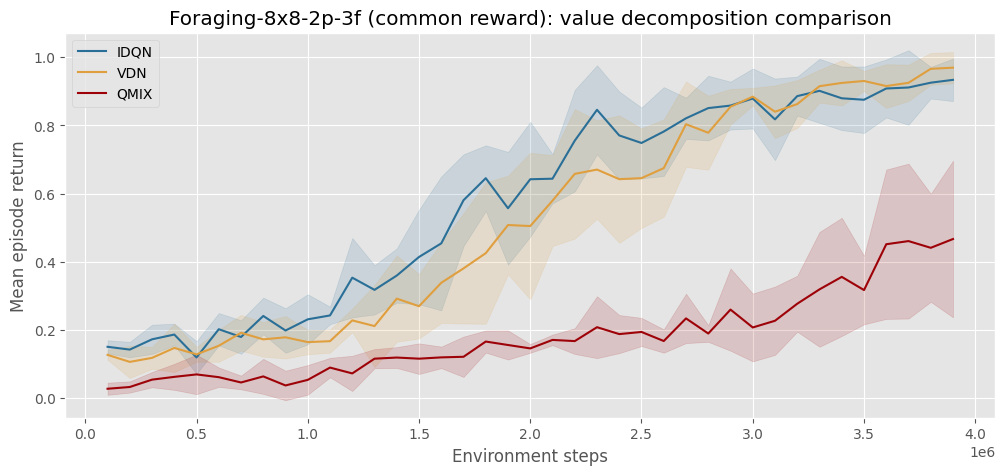

In [11]:
compare_algorithms('deep_marl_data/lbf_8x8-2p-3f_coop',
                   'Foraging-8x8-2p-3f (common reward): value decomposition comparison')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ולידציה של הריצה העצמית — אם הריצה האופציונלית של המיליון בוצעה, משרטטים את עקומת התשואה שלה על גבי המיליון הראשון של עקומות ה-IDQN המסופקות (ממוצע 5 seeds עם רצועת סטיית תקן). ריצה תקינה אמורה ליפול בתוך הרצועה או בסמוך לה. אם קיימות מספר ריצות תחת outputs (למשל גם ריצת השפיות), נטענת האחרונה ומסוננות נקודות ההערכה של 100 אלף הצעדים הראשונים כדי לדלג על שאריות ריצת השפיות.</p>
</div>

own run vs provided IDQN (36 own evaluations, every 4th shown)
  Own step     Own  Provided mean  Provided std
    100088   0.105          0.150         0.019
    200181   0.137          0.142         0.023
    300229   0.160          0.172         0.043
    400361   0.156          0.186         0.032
    500461   0.141          0.119         0.048
    600534   0.173          0.201         0.047
    700630   0.205          0.178         0.049
    800744   0.241          0.240         0.054
    900792   0.210          0.198         0.065

final: own 0.250 at step 975860 | provided 0.230 ± 0.074 at step 1000159 | within one std: yes


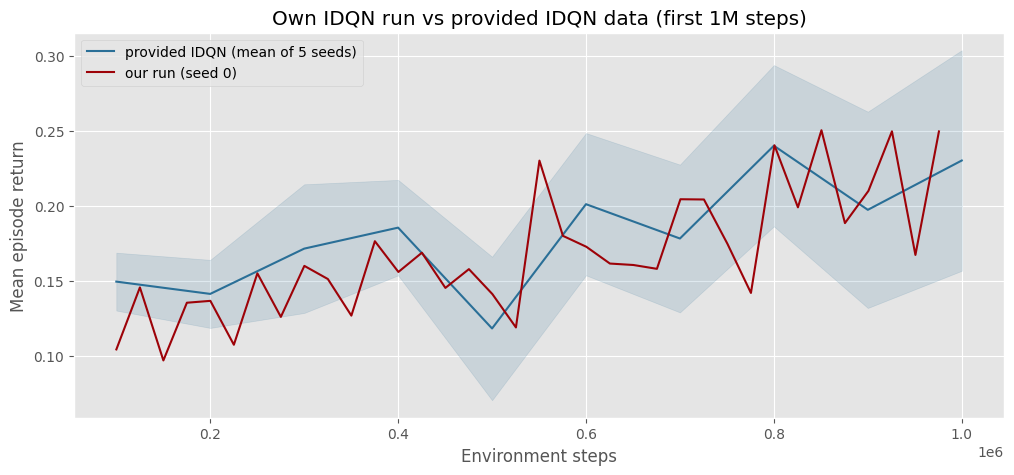

In [12]:
own_csvs = sorted(glob.glob('marl-book-codebase/marlbase/outputs/lbforaging*/idqn/*/results.csv'), key=os.path.getmtime)

steps, returns = load_algorithm_runs('deep_marl_data/lbf_8x8-2p-3f_coop', 'idqn')
mean, std = returns.mean(axis=0), returns.std(axis=0)
mask = steps <= 1_100_000

if own_csvs:
    df_own = pd.read_csv(own_csvs[-1])
    df_own = df_own[df_own['environment_steps'] > 100000] if len(own_csvs) > 1 else df_own
    own_steps = df_own['environment_steps'].values
    own_ret = df_own['mean_episode_returns'].values
    every = 4
    print(f'own run vs provided IDQN ({len(df_own)} own evaluations, every {every}th shown)')
    print(f"{'Own step':>10}{'Own':>8}{'Provided mean':>15}{'Provided std':>14}")
    for e in range(0, len(own_steps), every):
        j = int(np.argmin(np.abs(steps - own_steps[e])))
        print(f'{int(own_steps[e]):>10}{own_ret[e]:>8.3f}{mean[j]:>15.3f}{std[j]:>14.3f}')
    j = int(np.argmin(np.abs(steps - own_steps[-1])))
    verdict = 'yes' if abs(own_ret[-1] - mean[j]) <= std[j] else 'no'
    print()
    print(f'final: own {own_ret[-1]:.3f} at step {int(own_steps[-1])} | provided {mean[j]:.3f} ± {std[j]:.3f}'
          f' at step {int(steps[j])} | within one std: {verdict}')
else:
    print('no own run found under outputs/ - showing provided data only')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(steps[mask], mean[mask], color='#2a6f97', label='provided IDQN (mean of 5 seeds)')
ax.fill_between(steps[mask], (mean - std)[mask], (mean + std)[mask], alpha=0.15, color='#2a6f97')
if own_csvs:
    ax.plot(own_steps, own_ret, color='#9d0208', label='our run (seed 0)')
ax.set_xlabel('Environment steps')
ax.set_ylabel('Mean episode return')
ax.set_title('Own IDQN run vs provided IDQN data (first 1M steps)')
ax.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח השוואת האלגוריתמים ב-level-based foraging:</p>
<ul>
<li>VDN מסיים ראשון (0.97±0.05, ארבעה מחמישה seeds על 0.97 ומעלה) ו-IDQN צמוד אליו (0.93±0.06) — הפרש קטן מסטיית התקן; במשימה שיתופית פשוטה הפירוק האדיטיבי אינו הכרחי, אך גם אינו מזיק</li>
<li>קצב הלמידה הפוך מהדירוג הסופי: IDQN מוביל לאורך רוב האימון (0.58 מול 0.38 בצעד 1.7 מיליון) ו-VDN סוגר ועוקף רק לקראת הסוף</li>
<li>QMIX קורס: 0.47±0.23, עם פער עצום בין seeds (0.21 עד 0.74) — המורכב מהשלושה הוא היחיד שאינו פותר את המשימה בתקציב; עקומתו עדיין מטפסת בסופו (0.46 בצעד 3.7 מיליון), כך שחלק מהפער הוא איטיות ולא רק כישלון</li>
<li>חמישה seeds — לעומת שלושה בנתוני מטלה 2 — נותנים למסקנה גב: הפערים אינם רעש</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מדדים נוספים — משפחת ה-DQN מתעדת עמודות שונות ממשפחת ה-actor-critic של מטלה 2: אין entropy או actor/value loss; במקומם יש loss (הפסד ה-TD של רשת ה-Q), epsilon (מסלול החקירה — מקבילו העמוק של תזמון האפסילון שהשווינו במטלה 1; מוגדר ב-configs/algorithm/idqn.yaml), updates, וכן עמודות תשואה פר-סוכן (agent0/..., agent1/...).</p>
</div>

TD loss and exploration epsilon (39 evaluations, every 4th shown)
  Eval     Steps     IDQN      VDN     QMIX   epsilon
     1    100013   1.8018   0.9485 110.6497     0.762
     5    500084   1.5612   0.7972  99.8139     0.050
     9    900150   1.2868   0.5058  24.9976     0.050
    13   1300239   2.3496   0.6219   4.6142     0.050
    17   1700328   3.0184   1.1276   1.3014     0.050
    21   2100373   3.2302   1.7778   1.1706     0.050
    25   2500491   2.9927   2.0456   1.0065     0.050
    29   2900564   2.5669   1.9467   1.4106     0.050
    33   3300618   2.1434   1.6299   2.3580     0.050
    37   3700646   1.8628   1.2193   2.1193     0.050

 IDQN loss: first 1.8018 | last 1.7281 | max 3.5723 (step 2200408)
  VDN loss: first 0.9485 | last 1.0979 | max 2.2917 (step 2800556)
 QMIX loss: first 110.6497 | last 2.4216 | max 174.9975 (step 200015)
epsilon: first 0.762 | from step 400k onward 0.050


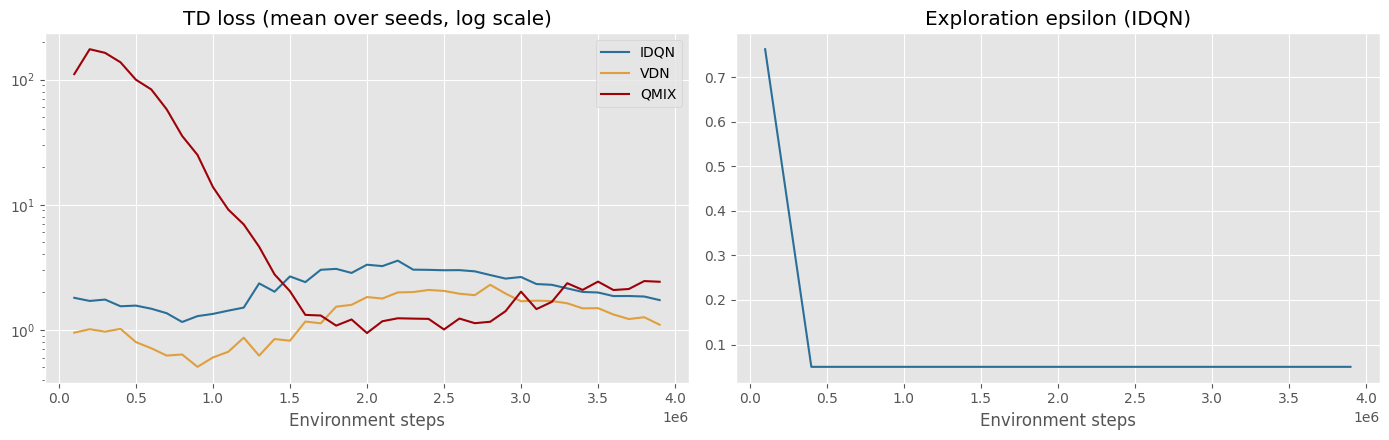

In [13]:
env_dir = 'deep_marl_data/lbf_8x8-2p-3f_coop'

every = 4
loss = {algo: load_algorithm_runs(env_dir, algo, 'loss')[1].mean(axis=0) for algo in ALGORITHMS}
steps, eps_runs = load_algorithm_runs(env_dir, 'idqn', 'epsilon')
eps = eps_runs.mean(axis=0)
print(f'TD loss and exploration epsilon ({len(steps)} evaluations, every {every}th shown)')
print(f"{'Eval':>6}{'Steps':>10}" + ''.join(f'{algo.upper():>9}' for algo in ALGORITHMS) + f"{'epsilon':>10}")
for e in range(0, len(steps), every):
    print(f'{e + 1:>6}{int(steps[e]):>10}' + ''.join(f'{loss[algo][e]:>9.4f}' for algo in ALGORITHMS)
          + f'{eps[e]:>10.3f}')
print()
for algo in ALGORITHMS:
    print(f'{algo.upper():>5} loss: first {loss[algo][0]:.4f} | last {loss[algo][-1]:.4f}'
          f' | max {loss[algo].max():.4f} (step {int(steps[loss[algo].argmax()])})')
print(f'epsilon: first {eps[0]:.3f} | from step 400k onward {eps[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for algo in ALGORITHMS:
    axes[0].plot(steps, loss[algo], label=algo.upper(), color=COLORS[algo])
axes[0].set_xlabel('Environment steps')
axes[0].set_yscale('log')
axes[0].set_title('TD loss (mean over seeds, log scale)')
axes[0].legend()
axes[1].plot(steps, eps, color='#2a6f97')
axes[1].set_xlabel('Environment steps')
axes[1].set_title('Exploration epsilon (IDQN)')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח המדדים:</p>
<ul>
<li>האפסילון דועך לינארית מ-1.0 ל-0.05 כבר בתוך 400 אלף צעדים: הריצות המסופקות הוגדרו עם eps_decay_over=0.1 ולא 0.5 של ברירת המחדל (מתועד ב-config.yaml של הריצות) — רוב האימון מתנהל בניצול כמעט מלא, בדומה לתזמון הלינארי ממטלה 1 שסיים את החקירה מוקדם</li>
<li>הפסד ה-QMIX נפתח בסדרי גודל מעל האחרים (110 עד 175 מול 1 עד 2, ראו סקאלה לוגריתמית) ומתנרמל רק סביב 1.5 מיליון צעדים — בדיוק כשהתשואה שלו מתחילה לעלות; רשת הערבול מוסיפה אי-יציבות אימון שמסבירה את הפיגור</li>
<li>הפסדי IDQN ו-VDN עולים דווקא באמצע האימון (שיאים 3.6 ו-2.3 סביב 2.2 עד 2.8 מיליון) כשהתשואות מטפסות — יעדי ה-TD נעים עם המדיניות, הגרסה הערכית של אי-הסטציונריות שראינו בהפסד ה-critic במטלה 2 — ואז מתמתנים; VDN הנמוך והחלק מבין השלושה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סרטוני התקדמות — לכל ריצה מצורפים חמישה סרטוני rollout שנשמרו לאורך האימון (בצעדים כ-200 אלף, 1, 2, 3 ו-3.8 מיליון). הפונקציה מאתרת את סרטוני הריצה, ממיינת לפי צעד האימון ומטמיעה את המבוקש — which=0 המוקדם ביותר, which=-1 המאוחר ביותר. מומלץ להטמיע במחברת ארבעה עד שישה סרטונים לכל היותר (כל הטמעה מגדילה את קובץ המחברת בכמחצית המגה־בייט), ולבחור אותם לפי מה שמשרת את הניתוח.</p>
</div>

In [14]:
def show_video(env_dir, algo, seed, which=-1, width=520):
    vids = sorted(glob.glob(f'deep_marl_data/{env_dir}/{algo}/{seed}/videos/*.mp4'),
                  key=lambda p: int(p.split('step-')[1].split('.')[0]))
    path = vids[which]
    print(path)
    data = b64encode(open(path, 'rb').read()).decode()
    return HTML(f'<video width="{width}" controls loop><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סרטון מוקדם (צעד 200 אלף) מול מאוחר (3.8 מיליון) — VDN seed 0; שני הסוכנים (אפור) ושלושת הפריטים (אדום) על לוח 8x8.</p>
</div>

In [15]:
display(show_video('lbf_8x8-2p-3f_coop', 'vdn', 0, which=0))
display(show_video('lbf_8x8-2p-3f_coop', 'vdn', 0, which=-1))

deep_marl_data/lbf_8x8-2p-3f_coop/vdn/0/videos/step-200035.mp4


deep_marl_data/lbf_8x8-2p-3f_coop/vdn/0/videos/step-3800321.mp4


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הסרטונים:</p>
<ul>
<li>בסרטון המוקדם (צעד 200 אלף) נאסף לכל היותר פריט אחד משלושה בכל אפיזודה — במאה פריימים דגומים לרוחב הסרטון ספירת הפריטים על הלוח לא יורדת מ-2</li>
<li>בסרטון המאוחר (3.8 מיליון) האפיזודה הראשונה נסגרת בתוך 28 צעדים — שלושה איסופים בפריימים 18, 22 ו-28, בתוך השנייה הראשונה — והאפיזודות מסתיימות מוקדם לכל אורכו: איפוסים בכל 15 עד 25 פריימים לעומת מגבלת 50 הצעדים, כשהסוכנים מתכנסים יחד על הפריטים</li>
<li>הקישור לטבלה: תשואה סופית של 0.97 פירושה כמעט כל המזון בכל אפיזודה — וזה בדיוק מה שנראה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פירוק ערך בסביבת SMAClite — סביבה שיתופית לחלוטין המשחזרת בקירוב את SMAC: כל סוכן שולט ביחידה בודדת, הקבוצה נדרשת להכריע קבוצת יחידות אויב המנוהלת על ידי AI מובנה, כל הסוכנים מקבלים תגמול זהה ורואים מידע חלקי בלבד. שני התרחישים המסופקים (3 seeds כל אחד):</p>
<ul>
<li>2s3z — שני Stalkers (יחידות טווח) ושלושה Zealots (יחידות קרב-פנים) מול הרכב זהה של האויב</li>
<li>2s_vs_1sc — שני Stalkers מול Spine Crawler בודד: תרחיש שבו נדרש תיאום הדוק של התחלפות בספיגת האש</li>
</ul>
</div>

SMAClite 2s3z: value decomposition comparison: mean return over seeds (every 4th evaluation)
  Eval       Steps     IDQN      VDN     QMIX
     1       50019    64.83    52.57    53.84
     5      250102    56.14    64.47    59.52
     9      450253    82.12    71.97    60.52
    13      650351    73.93    84.12    82.43
    17      850588    90.48    83.96    92.27
    21     1050729    92.42    97.60    81.06
    25     1250816    85.42    96.91    97.60
    29     1450957    86.91    96.69    97.07
    33     1651040    96.82    98.87    90.23
    37     1851163    97.90    98.13    92.88

        final mean  std/seeds   per-seed final returns
  IDQN       96.45       3.55   91.46  99.31  98.60
   VDN       98.46       0.89   99.70  98.07  97.63
  QMIX       98.36       1.59   99.54  99.43  96.11


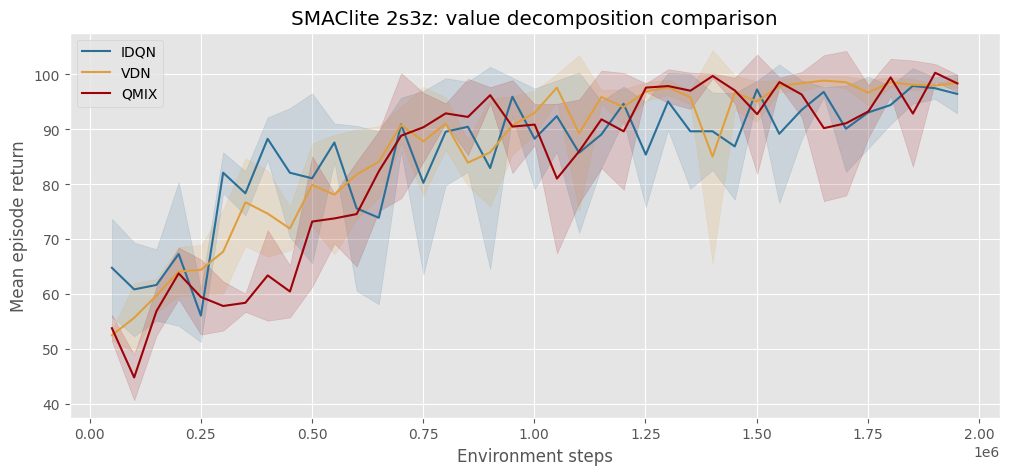

In [16]:
compare_algorithms('deep_marl_data/smaclite_2s3z', 'SMAClite 2s3z: value decomposition comparison')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התרחיש השני — 2s_vs_1sc: שני Stalkers מול Spine Crawler בודד; תרחיש חקירה קשה שבו הניצחון דורש התנהגות מתואמת שקשה לגלות באקראי.</p>
</div>

SMAClite 2s_vs_1sc: value decomposition comparison: mean return over seeds (every 4th evaluation)
  Eval       Steps     IDQN      VDN     QMIX
     1      100026    19.65    19.59    19.52
     5      500183     5.80     0.58     0.11
     9      900380    19.64     1.66     1.50
    13     1300703    23.64     9.89    14.13
    17     1700754    24.64     9.96    19.44
    21     2100800    31.75    16.41    21.64
    25     2500859    31.83    26.98    22.95
    29     2901174    32.23    28.93    32.88
    33     3301246    32.27    32.70    32.02
    37     3701289    34.42    33.92    34.63

        final mean  std/seeds   per-seed final returns
  IDQN       33.83       0.63   34.68  33.16  33.66
   VDN       32.42       3.33   28.08  36.18  33.00
  QMIX       34.06       2.50   32.61  31.99  37.58


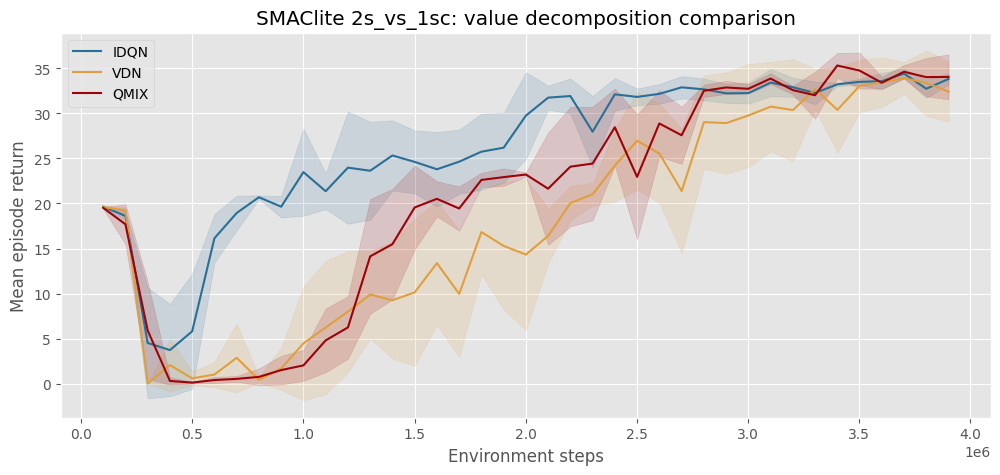

In [17]:
compare_algorithms('deep_marl_data/smaclite_2s_vs_1sc', 'SMAClite 2s_vs_1sc: value decomposition comparison')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אחוזי ניצחון — התשואה ב-SMAClite צוברת נקודות גם על נזק חלקי לאויב, ולכן תשואה גבוהה אינה בהכרח ניצחון; העמודה mean_battle_won מודדת את מה שחשוב באמת — שיעור הקרבות שבהם צוות הסוכנים השמיד את כוח האויב. הטבלה והגרף משווים את שלושת האלגוריתמים לפי מדד זה בשני התרחישים.</p>
</div>

SMAClite 2s3z: win rate over seeds (every 4th evaluation)
  Eval     Steps     IDQN      VDN     QMIX
     1     50019     0.21     0.00     0.01
     5    250102     0.08     0.04     0.01
     9    450253     0.55     0.16     0.03
    13    650351     0.41     0.44     0.40
    17    850588     0.74     0.49     0.71
    21   1050729     0.80     0.92     0.56
    25   1250816     0.62     0.89     0.90
    29   1450957     0.66     0.89     0.89
    33   1651040     0.89     0.95     0.80
    37   1851163     0.92     0.93     0.85

        final mean  std/seeds   per-seed final win rate
  IDQN       0.877      0.090   0.75  0.94  0.94
   VDN       0.950      0.024   0.98  0.95  0.92
  QMIX       0.933      0.052   0.98  0.96  0.86

SMAClite 2s_vs_1sc: win rate over seeds (every 4th evaluation)
  Eval     Steps     IDQN      VDN     QMIX
     1    100026     0.00     0.00     0.00
     5    500183     0.00     0.00     0.00
     9    900380     0.00     0.00     0.00
    13   13007

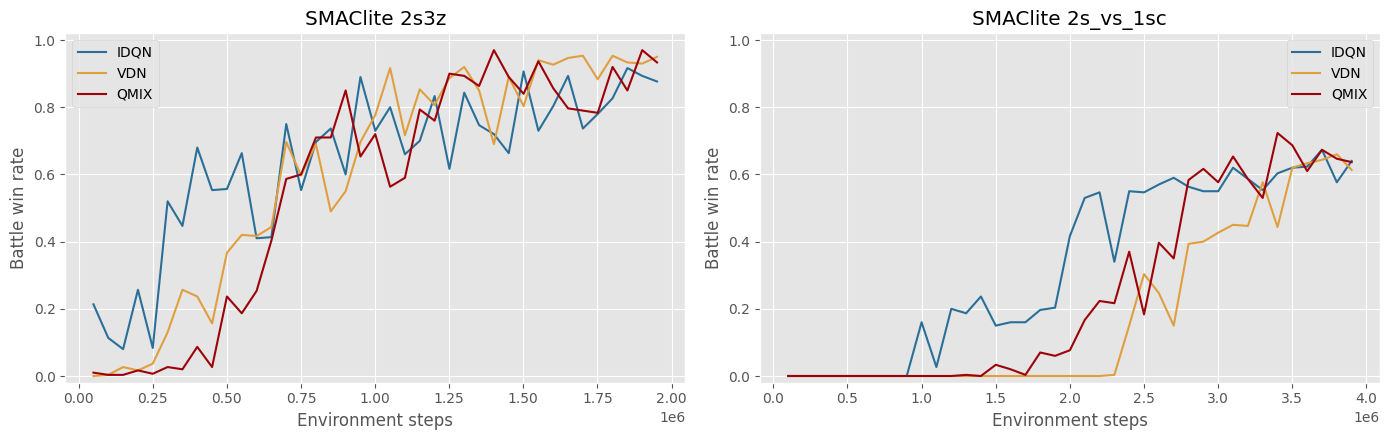

In [18]:
SCENARIOS = [('deep_marl_data/smaclite_2s3z', 'SMAClite 2s3z'),
             ('deep_marl_data/smaclite_2s_vs_1sc', 'SMAClite 2s_vs_1sc')]

every = 4
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (env_dir, title) in zip(axes, SCENARIOS):
    data = {algo: load_algorithm_runs(env_dir, algo, 'mean_battle_won') for algo in ALGORITHMS}
    steps = data['idqn'][0]
    print(f'{title}: win rate over seeds (every {every}th evaluation)')
    print(f"{'Eval':>6}{'Steps':>10}" + ''.join(f'{algo.upper():>9}' for algo in ALGORITHMS))
    for e in range(0, len(steps), every):
        print(f'{e + 1:>6}{int(steps[e]):>10}' + ''.join(f'{data[algo][1].mean(axis=0)[e]:>9.2f}' for algo in ALGORITHMS))
    print()
    print(f"{'':>6}{'final mean':>12}{'std/seeds':>11}   per-seed final win rate")
    for algo in ALGORITHMS:
        finals = data[algo][1][:, -1]
        print(f'{algo.upper():>6}{finals.mean():>12.3f}{finals.std():>11.3f}   '
              + '  '.join(f'{f:.2f}' for f in finals))
    print()
    for algo in ALGORITHMS:
        ax.plot(steps, data[algo][1].mean(axis=0), label=algo.upper(), color=COLORS[algo])
    ax.set_xlabel('Environment steps')
    ax.set_ylabel('Battle win rate')
    ax.set_title(title)
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח השוואת SMAClite:</p>
<ul>
<li>בתשואות שני התרחישים נראים תיקו: 96.5, 98.5 ו-98.4 ב-2s3z; 33.8, 32.4 ו-34.1 ב-2s_vs_1sc — הפרשים בתוך סטיית התקן</li>
<li>אחוזי הניצחון שוברים את התיקו ב-2s3z: IDQN מנצח 87.7% (עם seed שנתקע על 0.75) מול 95.0%±2.4 של VDN ו-93.3% של QMIX — תשואה שנצברת מנזק חלקי מסתירה פער אמיתי, והפירוק משפר גם את המדד וגם את יציבותו</li>
<li>ב-2s_vs_1sc התמונה הפוכה ובממד הזמן: IDQN מתחיל לנצח מצעד 1.3 מיליון, בעוד VDN אינו מנצח אף קרב עד 2.3 מיליון ו-QMIX עד 2.1 מיליון; שלושתם מתכנסים ל-61 עד 64 אחוזים — בתרחיש חקירה קשה הפירוק דווקא מאט את גילוי האסטרטגיה המנצחת</li>
<li>המסקנה הדו-צדדית: פירוק ערך קונה אמינות ויציבות בתרחיש הקרב הסימטרי, ומשלם בקצב למידה בתרחיש האסימטרי — ובחירת המדד (תשואה מול ניצחון) משנה את המסקנה כולה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סרטוני 2s3z — מוקדם (צעד 100 אלף) מול מאוחר (1.9 מיליון), VDN seed 0: חמש יחידות (שני Stalkers טווח ושלושה Zealots קרב-פנים) מול צוות אויב זהה בשליטת ה-AI המובנה.</p>
</div>

In [19]:
display(show_video('smaclite_2s3z', 'vdn', 0, which=0))
display(show_video('smaclite_2s3z', 'vdn', 0, which=-1))

Output hidden; open in https://colab.research.google.com to view.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סרטוני 2s_vs_1sc — מוקדם (צעד 200 אלף) מול מאוחר (3.8 מיליון), VDN seed 0: שני Stalkers מול Spine Crawler בודד — מבנה סטטי בעל טווח וכוח אש גבוהים, הדורש תיאום כדי להפילו בלי להימחק.</p>
</div>

In [20]:
display(show_video('smaclite_2s_vs_1sc', 'vdn', 0, which=0))
display(show_video('smaclite_2s_vs_1sc', 'vdn', 0, which=-1))

deep_marl_data/smaclite_2s_vs_1sc/vdn/0/videos/step-200001.mp4


deep_marl_data/smaclite_2s_vs_1sc/vdn/0/videos/step-3800708.mp4


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח התנהגויות מהסרטונים:</p>
<ul>
<li>2s3z, מוקדם (100 אלף) מול מאוחר (1.9 מיליון): בסרטון המוקדם הצוות נמחק — חמישה מצבי מחיקת-צוות ואפס מצבי ניצחון בפריימים הדגומים; במאוחר אפס מחיקות, ובניצחונות הנדגמים 47 עד 77 אחוזים מכוח הצוות שורדים את הקרב; הקרבות קצרים ומוכרעים — 40 עד 50 צעדים מתוך מגבלת 150</li>
<li>2s_vs_1sc, מוקדם (200 אלף) מול מאוחר (3.8 מיליון): במוקדם שני ה-Stalkers נעים כצמד צמוד במרחק כמעט זהה מה-Spine Crawler (פער של 36 פיקסלים בין הקרוב לרחוק) וקיימים פריימים שבהם שניהם מתים; במאוחר נראית חלוקת תפקידים — אחד מתקרב (177 פיקסלים) והשני שומר מרחק (242, פער כפול) — ואין ולו מחיקת-צוות אחת; ההתנהגות עקבית עם משיכת אש לסירוגין, האסטרטגיה הנדרשת בתרחיש</li>
<li>שיטת המדידה, כבניתוח הגודש במטלה 2: זיהוי יחידות לפי צבע (ירוק — בעלות הברית, אדום — אויב) ומדידת שטחים ומרחקים על פריימים דגומים, כך שהטענות נשענות על ספירה ולא על התרשמות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייצוא התוצאות ל-CSV — נתוני המחברת נשמרים ל-Drive, קובץ לכל מקור:</p>
<ul>
<li>hw3_lbf_idqn_own.csv — הריצה העצמית של IDQN (נכתב רק אם הריצה האופציונלית בוצעה)</li>
<li>hw3_lbf_8x8-2p-3f_coop.csv — הנתונים המסופקים ב-level-based foraging, 3 אלגוריתמים × 5 seeds</li>
<li>hw3_smaclite_2s3z.csv ו-hw3_smaclite_2s_vs_1sc.csv — שני תרחישי SMAClite, 3 אלגוריתמים × 3 seeds כל אחד</li>
</ul>
<p>קובץ נפרד לכל סביבה ולא מיזוג יחיד, משום שמספר הסוכנים שונה ביניהן (2 ב-level-based foraging ו-2s_vs_1sc, 5 ב-2s3z) ומיזוג היה מייצר עמודות תשואה פר-סוכן ריקות. הקבצים נכתבים כפי שהם מגיעים מ-results.csv של ה-codebase, ללא עיבוד וללא חיתוך לאורך המשותף, כך שנשמר מלוא המידע של כל seed.</p>
</div>

In [21]:
paths = {}

if own_csvs:
    paths['own run'] = os.path.join(DRIVE_PATH, 'hw3_lbf_idqn_own.csv')
    df_own.to_csv(paths['own run'], index=False)

for env_dir in DIRS:
    frames = []
    for algo in ALGORITHMS:
        for path in sorted(glob.glob(f'deep_marl_data/{env_dir}/{algo}/*/results.csv')):
            seed = os.path.basename(os.path.dirname(path))
            frames.append(pd.read_csv(path).assign(algorithm=algo, seed=seed))
    df = pd.concat(frames, ignore_index=True)
    df = df[['algorithm', 'seed'] + [c for c in df.columns if c not in ('algorithm', 'seed')]]
    paths[env_dir] = os.path.join(DRIVE_PATH, f'hw3_{env_dir}.csv')
    df.to_csv(paths[env_dir], index=False)

for name, path in paths.items():
    print(f'{name:22} -> {os.path.basename(path):34} {len(pd.read_csv(path)):>5} rows')

own run                -> hw3_lbf_idqn_own.csv                  36 rows
lbf_8x8-2p-3f_coop     -> hw3_lbf_8x8-2p-3f_coop.csv           585 rows
smaclite_2s3z          -> hw3_smaclite_2s3z.csv                351 rows
smaclite_2s_vs_1sc     -> hw3_smaclite_2s_vs_1sc.csv           351 rows


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שמירת הסרטונים ל-Drive — ששת סרטוני ה-rollout המוטמעים במחברת מועתקים בשמות מזהים, בתבנית HW3_[סביבה]_[אלגוריתם]_[שלב]_[צעד]. צעד האימון נגזר משם הקובץ המקורי, ולכן השמות משקפים את הצעדים בפועל — הנקודות שבהן נשמרו הסרטונים שונות בין הסביבות.</p>
</div>

In [22]:
VIDEO_LABELS = {'lbf_8x8-2p-3f_coop': 'lbf_2p3f',
                'smaclite_2s3z': 'smaclite_2s3z',
                'smaclite_2s_vs_1sc': 'smaclite_2s_vs_1sc'}

def save_video(env_dir, algo, seed, which):
    vids = sorted(glob.glob(f'deep_marl_data/{env_dir}/{algo}/{seed}/videos/*.mp4'),
                  key=lambda p: int(p.split('step-')[1].split('.')[0]))
    src = vids[which]
    step = int(src.split('step-')[1].split('.')[0])
    name = f"HW3_{VIDEO_LABELS[env_dir]}_{algo}_{'early' if which == 0 else 'late'}_{step // 1000}k.mp4"
    shutil.copyfile(src, os.path.join(DRIVE_PATH, name))
    return name

for env_dir in DIRS:
    for which in (0, -1):
        name = save_video(env_dir, 'vdn', 0, which)
        print(f'{name:44} {os.path.getsize(os.path.join(DRIVE_PATH, name)) / 1e6:>5.1f} MB')

HW3_lbf_2p3f_vdn_early_200k.mp4                0.1 MB
HW3_lbf_2p3f_vdn_late_3800k.mp4                0.2 MB
HW3_smaclite_2s3z_vdn_early_100k.mp4           1.1 MB
HW3_smaclite_2s3z_vdn_late_1900k.mp4           1.6 MB
HW3_smaclite_2s_vs_1sc_vdn_early_200k.mp4      0.5 MB
HW3_smaclite_2s_vs_1sc_vdn_late_3800k.mp4      0.5 MB


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום ומסקנות:</p>
<ul>
<li>ב-level-based foraging השיתופי הפירוק האדיטיבי שקול ללומד העצמאי (VDN 0.97 מול IDQN 0.93 על חמישה seeds), ו-QMIX ללא כוונון קורס (0.47±0.23) — מורכבות אינה מקנה יתרון אוטומטי, ועקומת ההפסד שלו (פתיחה בסדרי גודל מעל האחרים) מסמנת את המנגנון</li>
<li>ב-SMAClite התשואות מציגות תיקו אך אחוזי הניצחון לא: הפירוק עדיף ויציב בתרחיש הסימטרי 2s3z (95% מול 88%), ואיטי משמעותית בתרחיש החקירה 2s_vs_1sc (אפס ניצחונות עד 2.3 מיליון צעדים מול IDQN שמנצח מ-1.3 מיליון) — בחירת המדד קובעת את המסקנה</li>
<li>הסרטונים מראים את הלמידה עצמה: ממחיקות-צוות לניצחונות עם רוב הכוח שורד ב-2s3z, ומצמד צמוד לחלוקת תפקידים מול ה-Spine Crawler; ב-foraging — מאיסוף בודד לניקוי הלוח בתוך 28 צעדים</li>
<li>הקשת של שלוש המטלות: מטלה 1 חשפה את אי-הסטציונריות של לומדים עצמאיים בטבלאות; מטלה 2 הציגה את המענה במשפחת ה-policy gradient — critic מרכזי בפרדיגמת CTDE; מטלה 3 את המענה במשפחת הערך — פירוק ה-Q המשותף לתועלות אישיות. המסקנה החוזרת בשלושתן: הכלים המרכזיים קונים יציבות ולא בהכרח שיא ביצועים, מחיר המורכבות אמיתי, ומסקנות דורשות ריבוי seeds ומדדים נכונים</li>
</ul>
</div>